# Assignment: Data Preparation Basics



## Import Libraries and Load Data
Import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
credit_data = credit_data = pd.read_csv('/content/credit_customers.csv')

In [3]:
credit_data.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## Question 1: Exploratory Data Analysis (EDA)
Perform a brief initial exploration of the dataset.

- Display the number of rows, columns, and data types.
- Show descriptive statistics (mean, min, max, std) for numerical features.
- **Visualization Task:**
  - Create a histogram of age to understand the age distribution of applicants.
  - Create a bar chart of purpose to show the most common loan purposes.

In [4]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         909 non-null    object
 1   duration                1000 non-null   int64 
 2   credit_history          961 non-null    object
 3   purpose                 957 non-null    object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          987 non-null    object
 6   employment              987 non-null    object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      942 non-null    object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 931 non-null    object
 15  exist

In [5]:
# dtypes: int64(7), object(14)
# RangeIndex: 1000 entries, 0 to 999  (Not a big dataset)
# Data columns (total 21 columns)

In [6]:
credit_data.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


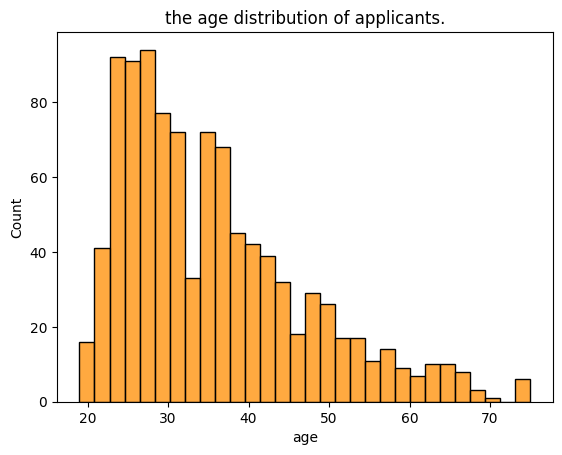

In [7]:
sns.histplot(data=credit_data,
             x='age',
             kde=False,
             bins=30,
             color='darkorange')
plt.title('the age distribution of applicants.')
plt.show()

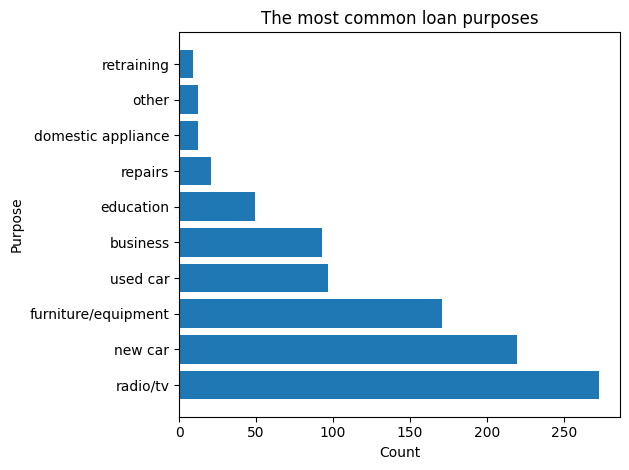

In [8]:
purpose_counts = credit_data.purpose.value_counts()
plt.barh(purpose_counts.index, purpose_counts.values)
plt.xlabel('Count')
plt.ylabel('Purpose')
plt.title('The most common loan purposes')
plt.tight_layout()
plt.show()

## Question 2: Handling Missing Values

- Identify missing values in the dataset.
- Choose and apply an appropriate handling technique (imputation or deletion).
- Explain why you chose this technique.
- **Visualization Task:** Before and after handling missing values, create a bar chart that shows the count of missing values per column.

In [9]:
numerical_data = credit_data.select_dtypes(['int64'])
categorical_data = credit_data.select_dtypes(['object'])

In [10]:
print(numerical_data.info())
print('\n--------------------------\n--------------------------\n')
print(categorical_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   duration                1000 non-null   int64
 1   credit_amount           1000 non-null   int64
 2   installment_commitment  1000 non-null   int64
 3   residence_since         1000 non-null   int64
 4   age                     1000 non-null   int64
 5   existing_credits        1000 non-null   int64
 6   num_dependents          1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB
None

--------------------------
--------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   checking_status      909 non-null    object
 1   credit_history       961 non-null    object
 2   purpose              957 non-

### as per the last check the numerical data in the dataset has no null values so I will be working on the hadling the missing values in the categorical data

In [11]:
categorical_imputer = SimpleImputer(strategy='constant', fill_value='unknown')

In [12]:
categorical_data_imputed = pd.DataFrame(categorical_imputer.fit_transform(categorical_data),
                                               columns=categorical_data.columns)
categorical_data_imputed.isnull().sum()

,0
checking_status,0
credit_history,0
purpose,0
savings_status,0
employment,0
personal_status,0
other_parties,0
property_magnitude,0
other_payment_plans,0
housing,0


In [13]:
credit_data[categorical_data_imputed.columns] = categorical_data_imputed
credit_data.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


In [14]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

## Question 3: Handling Duplicated Data

- Check if there are duplicated rows.
- Remove them if they exist.
- **Visualization Task:** Show a before vs. after comparison of dataset size using a simple bar chart or text-based comparison.

In [15]:
credit_data.duplicated().sum()

np.int64(0)

In [16]:
# no column has all unique elements (like the id) so there's no duplicates to be handled

## Question 4: Outlier Detection and Handling

- Detect outliers in numerical columns (e.g., credit_amount, age, duration) using a statistical method (like IQR or Z-score).
- **Visualization Task (Step 1):** Use boxplots to visualize outliers in at least two numerical features.
- Handle the outliers (remove or impute).
- **Visualization Task (Step 2):** Show the boxplots again after handling outliers to compare the effect.

In [17]:
numerical_data = credit_data.select_dtypes(['int64'])
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   duration                1000 non-null   int64
 1   credit_amount           1000 non-null   int64
 2   installment_commitment  1000 non-null   int64
 3   residence_since         1000 non-null   int64
 4   age                     1000 non-null   int64
 5   existing_credits        1000 non-null   int64
 6   num_dependents          1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


In [18]:
numerical_data.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [19]:
outlier_indices = {}

for col in numerical_data.columns:
    Q1 = numerical_data[col].quantile(0.25)
    Q3 = numerical_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (numerical_data[col] < lower) | (numerical_data[col] > upper)
    outlier_indices[col] = numerical_data[outlier_mask].index





In [20]:
outlier_indices

{'duration': Index([  1,  11,  29,  35,  36,  44,  63,  78,  95, 115, 130, 134, 145, 191,
        194, 226, 242, 255, 272, 273, 285, 286, 287, 294, 295, 304, 310, 332,
        333, 373, 374, 375, 444, 467, 522, 538, 549, 552, 568, 569, 615, 616,
        622, 637, 650, 657, 667, 672, 677, 685, 701, 706, 714, 728, 787, 788,
        813, 814, 829, 832, 887, 915, 921, 927, 938, 945, 973, 981, 998, 999],
       dtype='int64'),
 'credit_amount': Index([  5,  17,  18,  57,  63,  70,  78,  87,  95, 105, 130, 134, 136, 180,
        205, 226, 236, 268, 272, 274, 285, 291, 295, 304, 333, 373, 374, 378,
        381, 395, 402, 417, 431, 450, 491, 496, 509, 525, 549, 563, 615, 616,
        637, 645, 653, 657, 672, 684, 714, 736, 744, 763, 771, 805, 808, 812,
        818, 828, 832, 854, 881, 887, 895, 902, 915, 917, 921, 927, 945, 953,
        980, 983],
       dtype='int64'),
 'installment_commitment': Index([], dtype='int64'),
 'residence_since': Index([], dtype='int64'),
 'age': Index([  0,  75, 1

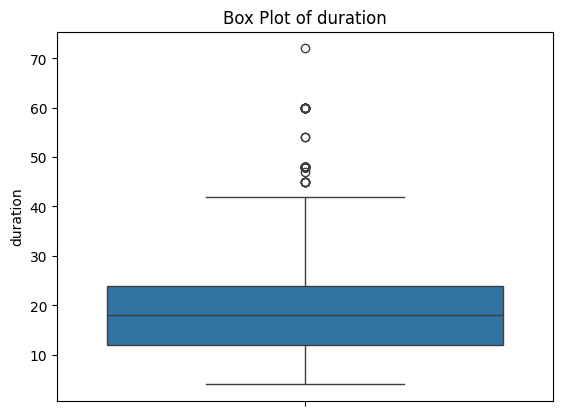

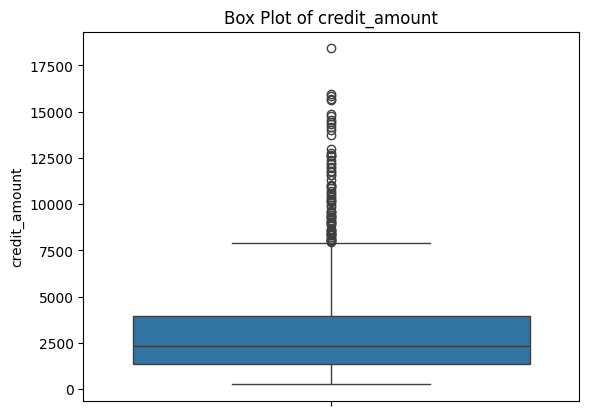

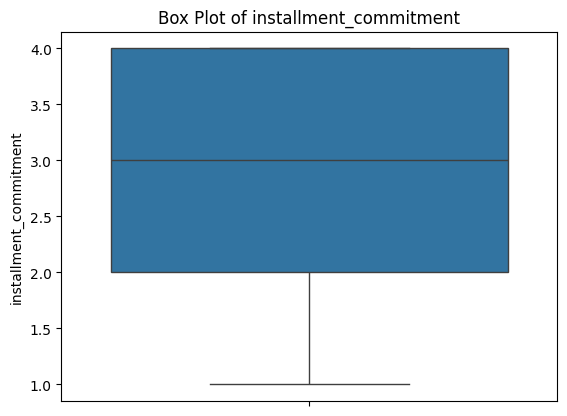

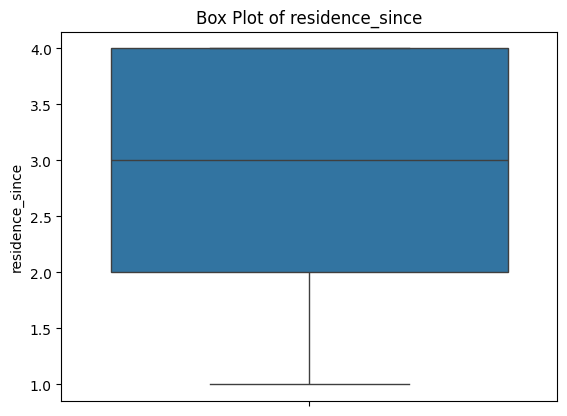

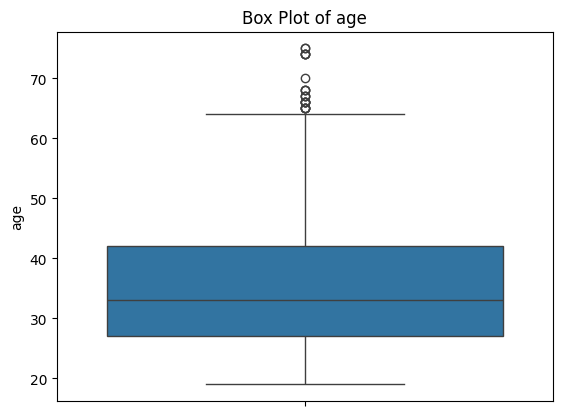

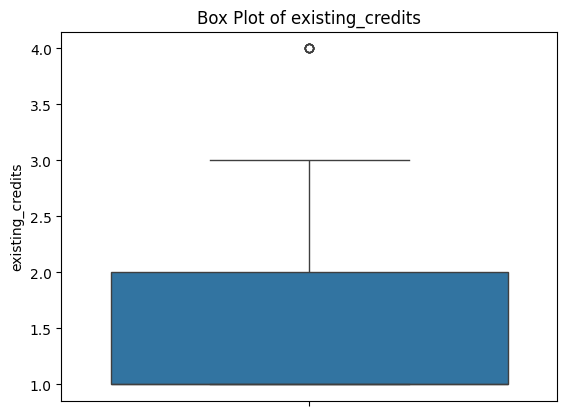

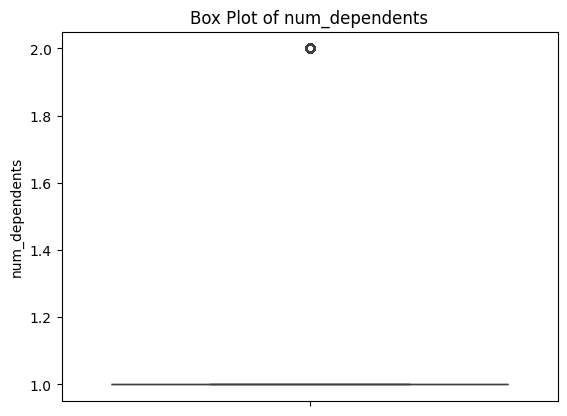

In [21]:
for col in numerical_data.columns:
  plt.figure()
  sns.boxplot(y=numerical_data[col])
  plt.title(f'Box Plot of {col}')
  plt.show()

In [22]:
cleaned_numerical_data = numerical_data.copy()

for col in numerical_data:
    Q1 = numerical_data[col].quantile(0.25)
    Q3 = numerical_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cleaned_numerical_data.loc[cleaned_numerical_data[col] < lower, col] = cleaned_numerical_data[col].median()
    cleaned_numerical_data.loc[cleaned_numerical_data[col] > upper, col] = cleaned_numerical_data[col].median()

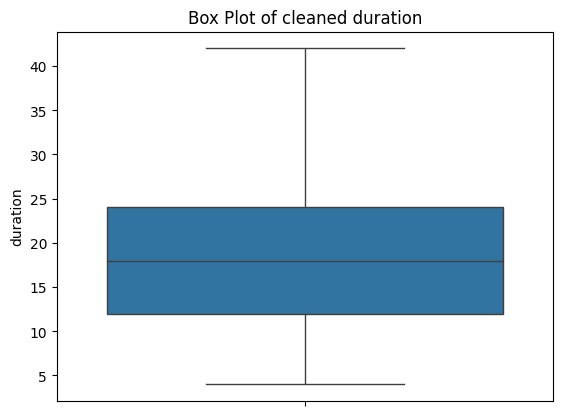

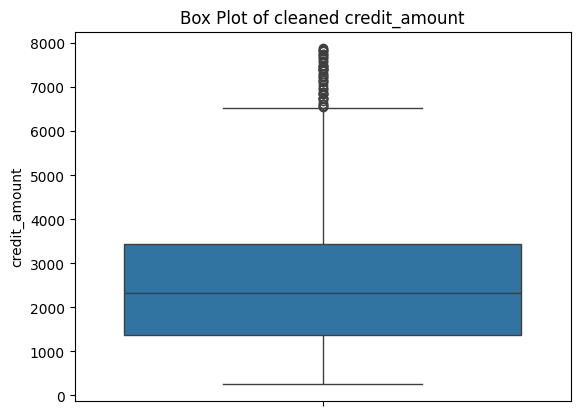

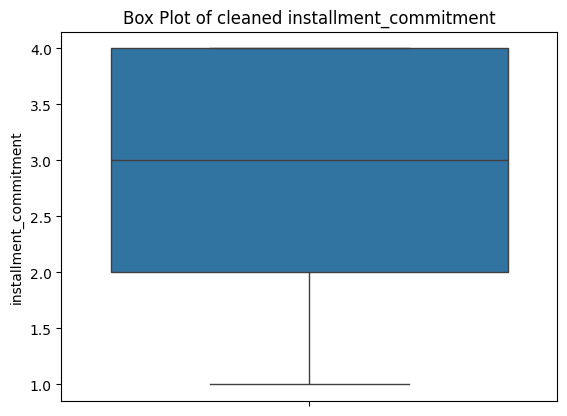

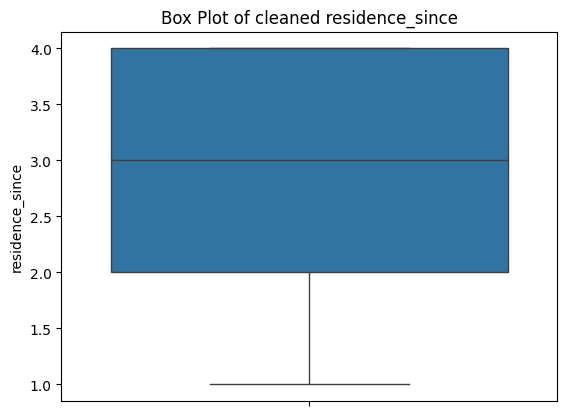

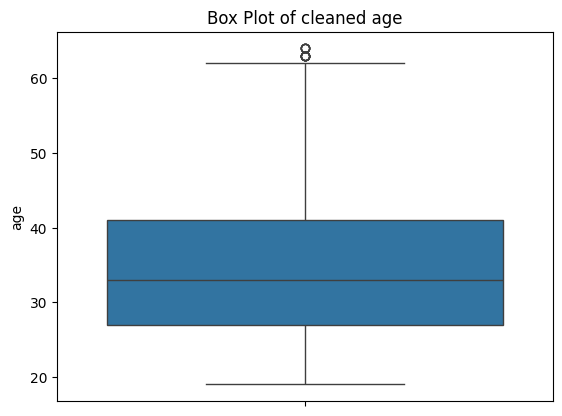

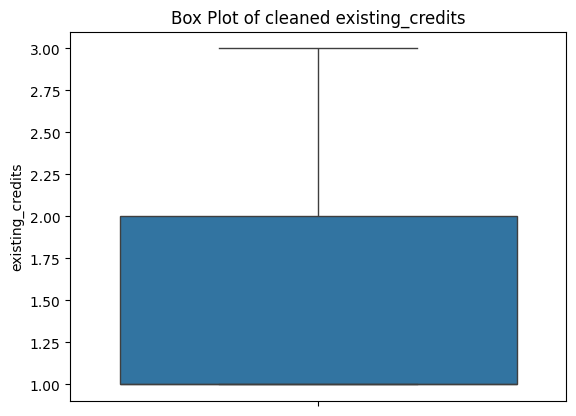

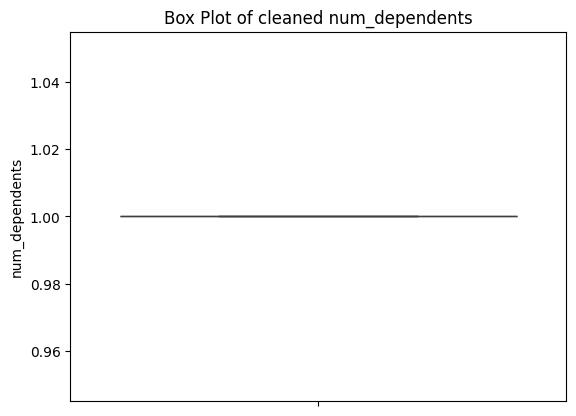

In [23]:
for col in cleaned_numerical_data:
  plt.figure()
  sns.boxplot(y=cleaned_numerical_data[col])
  plt.title(f'Box Plot of cleaned {col}')
  plt.show()

In [24]:
cleaned_numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                1000 non-null   int64  
 1   credit_amount           1000 non-null   float64
 2   installment_commitment  1000 non-null   int64  
 3   residence_since         1000 non-null   int64  
 4   age                     1000 non-null   int64  
 5   existing_credits        1000 non-null   int64  
 6   num_dependents          1000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


In [25]:
credit_data[cleaned_numerical_data.columns] = cleaned_numerical_data
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   object 
 1   duration                1000 non-null   int64  
 2   credit_history          1000 non-null   object 
 3   purpose                 1000 non-null   object 
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   object 
 6   employment              1000 non-null   object 
 7   installment_commitment  1000 non-null   int64  
 8   personal_status         1000 non-null   object 
 9   other_parties           1000 non-null   object 
 10  residence_since         1000 non-null   int64  
 11  property_magnitude      1000 non-null   object 
 12  age                     1000 non-null   int64  
 13  other_payment_plans     1000 non-null   object 
 14  housing                 1000 non-null   o

## Question 7: Splitting the Data

- Split the data into training and testing sets.
- Try at least two different split strategies (e.g., 70/30 vs. 80/20).


Decided to start at this point with spliting data to prevent information leakeage to the test data

In [26]:
features = credit_data.drop(columns=['class'])
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   object 
 1   duration                1000 non-null   int64  
 2   credit_history          1000 non-null   object 
 3   purpose                 1000 non-null   object 
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   object 
 6   employment              1000 non-null   object 
 7   installment_commitment  1000 non-null   int64  
 8   personal_status         1000 non-null   object 
 9   other_parties           1000 non-null   object 
 10  residence_since         1000 non-null   int64  
 11  property_magnitude      1000 non-null   object 
 12  age                     1000 non-null   int64  
 13  other_payment_plans     1000 non-null   object 
 14  housing                 1000 non-null   o

In [27]:
target = credit_data[['class']]
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [28]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=40)

In [29]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 970 to 326
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         800 non-null    object 
 1   duration                800 non-null    int64  
 2   credit_history          800 non-null    object 
 3   purpose                 800 non-null    object 
 4   credit_amount           800 non-null    float64
 5   savings_status          800 non-null    object 
 6   employment              800 non-null    object 
 7   installment_commitment  800 non-null    int64  
 8   personal_status         800 non-null    object 
 9   other_parties           800 non-null    object 
 10  residence_since         800 non-null    int64  
 11  property_magnitude      800 non-null    object 
 12  age                     800 non-null    int64  
 13  other_payment_plans     800 non-null    object 
 14  housing                 800 non-null    objec

In [30]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 970 to 326
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   800 non-null    object
dtypes: object(1)
memory usage: 12.5+ KB


## Question 5: Class Imbalance

- Check the balance between classes in the target variable (class).
- **Visualization Task:** Create a bar plot to show the distribution of "good" vs "bad" classes.
- If imbalance exists, apply a strategy to handle it.
- **Visualization Task (after balancing):** Show the updated class distribution with another bar plot.

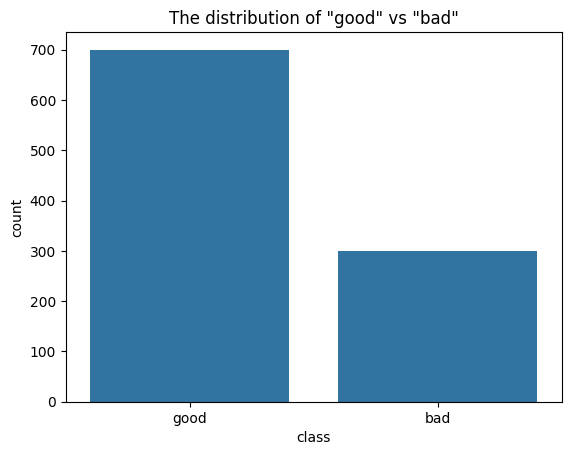

In [31]:
sns.countplot(x='class',  data=credit_data)
plt.title('The distribution of "good" vs "bad"')
plt.show()

### Choose random over sampler since mixed data (categorical & numerical)

In [32]:
random_over_sampler = RandomOverSampler()

In [33]:
x_train, y_train = random_over_sampler.fit_resample(x_train, y_train)

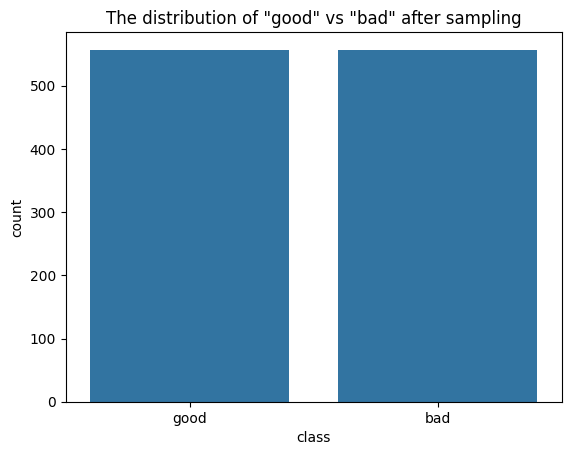

In [34]:
sns.countplot(x=y_train['class'])
plt.title('The distribution of "good" vs "bad" after sampling')
plt.show()

In [35]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1114 non-null   object 
 1   duration                1114 non-null   int64  
 2   credit_history          1114 non-null   object 
 3   purpose                 1114 non-null   object 
 4   credit_amount           1114 non-null   float64
 5   savings_status          1114 non-null   object 
 6   employment              1114 non-null   object 
 7   installment_commitment  1114 non-null   int64  
 8   personal_status         1114 non-null   object 
 9   other_parties           1114 non-null   object 
 10  residence_since         1114 non-null   int64  
 11  property_magnitude      1114 non-null   object 
 12  age                     1114 non-null   int64  
 13  other_payment_plans     1114 non-null   object 
 14  housing                 1114 non-null   

In [36]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   1114 non-null   object
dtypes: object(1)
memory usage: 8.8+ KB


## Question 6: Data Transformation

- Apply feature scaling (Min-Max scaling or Z-score normalization) to numerical features.
- **Visualization Task:** Show the distribution of one numerical feature before and after scaling using a histogram.
- Convert categorical variables into numerical format using one-hot encoding or label encoding.

In [37]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1114 non-null   object 
 1   duration                1114 non-null   int64  
 2   credit_history          1114 non-null   object 
 3   purpose                 1114 non-null   object 
 4   credit_amount           1114 non-null   float64
 5   savings_status          1114 non-null   object 
 6   employment              1114 non-null   object 
 7   installment_commitment  1114 non-null   int64  
 8   personal_status         1114 non-null   object 
 9   other_parties           1114 non-null   object 
 10  residence_since         1114 non-null   int64  
 11  property_magnitude      1114 non-null   object 
 12  age                     1114 non-null   int64  
 13  other_payment_plans     1114 non-null   object 
 14  housing                 1114 non-null   

In [38]:
x_train_num = x_train.select_dtypes(['int64','float64'])
x_train_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                1114 non-null   int64  
 1   credit_amount           1114 non-null   float64
 2   installment_commitment  1114 non-null   int64  
 3   residence_since         1114 non-null   int64  
 4   age                     1114 non-null   int64  
 5   existing_credits        1114 non-null   int64  
 6   num_dependents          1114 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 61.1 KB


In [39]:
x_test_num = x_test.select_dtypes(['int64','float64'])
x_test_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 204 to 988
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                200 non-null    int64  
 1   credit_amount           200 non-null    float64
 2   installment_commitment  200 non-null    int64  
 3   residence_since         200 non-null    int64  
 4   age                     200 non-null    int64  
 5   existing_credits        200 non-null    int64  
 6   num_dependents          200 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 12.5 KB


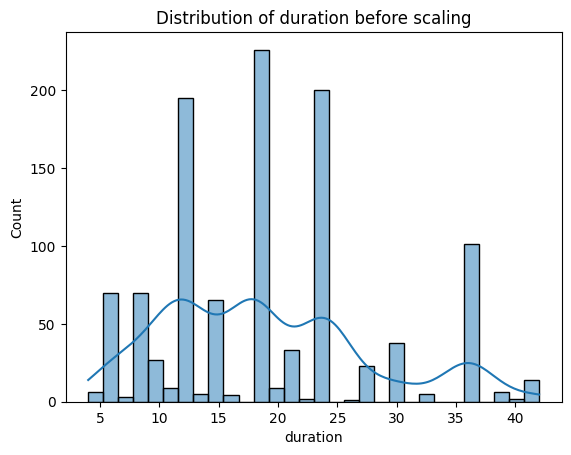

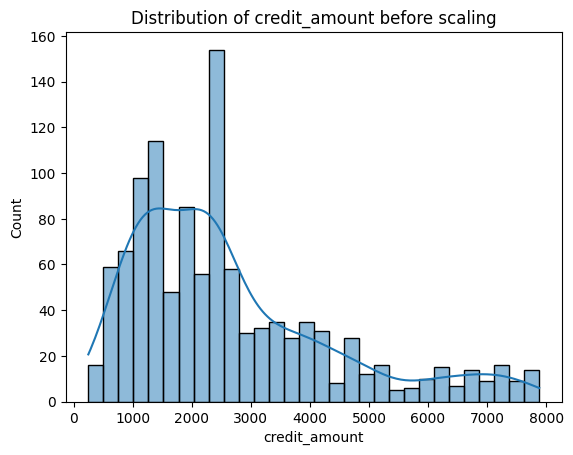

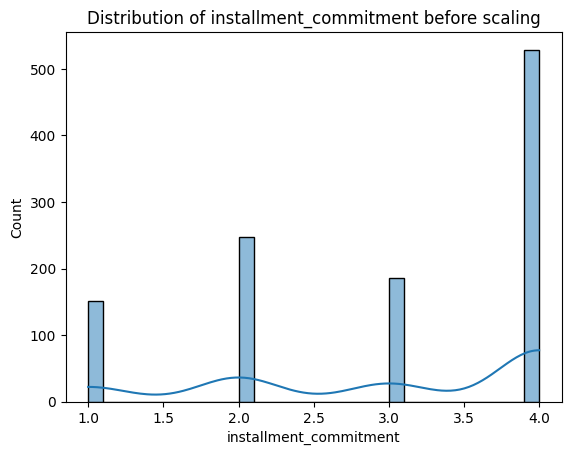

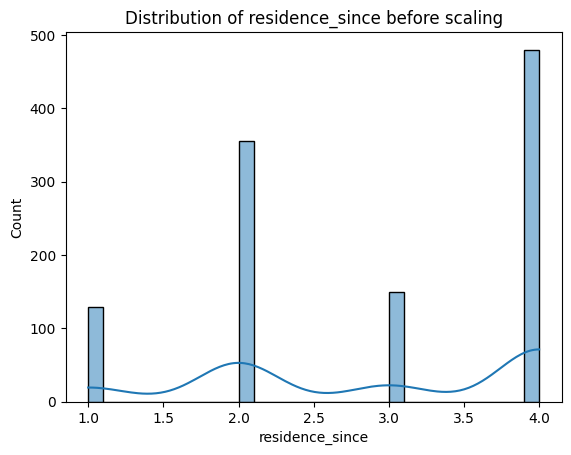

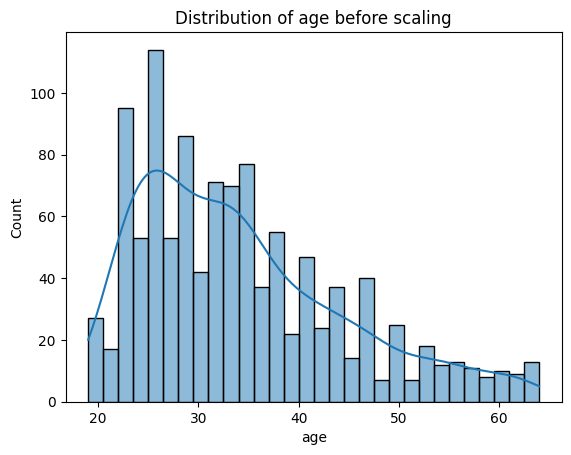

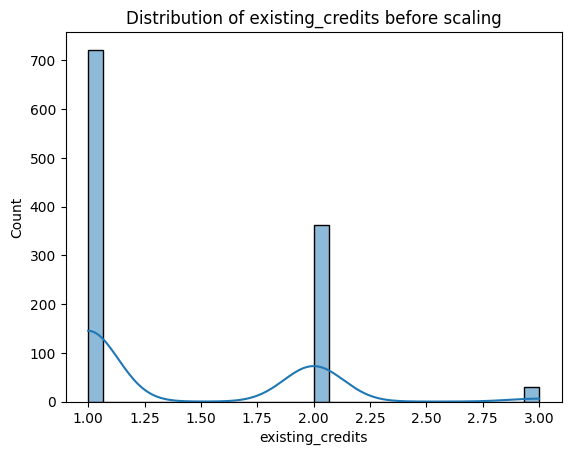

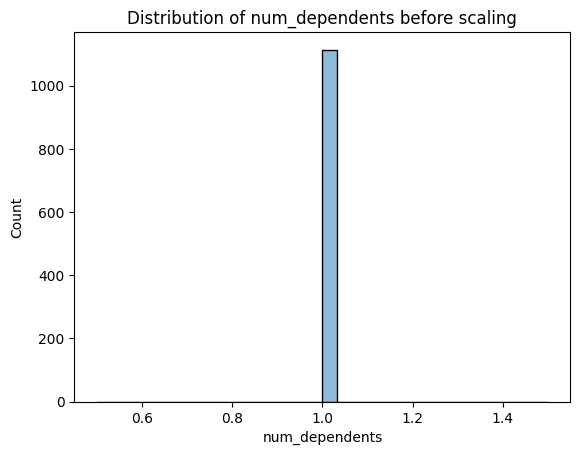

In [40]:
for col in x_train_num.columns:
  sns.histplot(x_train_num[col], kde=True, bins=30)
  plt.title(f'Distribution of {col} before scaling')
  plt.show()

In [41]:
MMscaler = MinMaxScaler()

In [42]:
x_train_num = pd.DataFrame(MMscaler.fit_transform(x_train_num),
                           columns = x_train_num.columns)
x_train_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                1114 non-null   float64
 1   credit_amount           1114 non-null   float64
 2   installment_commitment  1114 non-null   float64
 3   residence_since         1114 non-null   float64
 4   age                     1114 non-null   float64
 5   existing_credits        1114 non-null   float64
 6   num_dependents          1114 non-null   float64
dtypes: float64(7)
memory usage: 61.1 KB


In [43]:
x_test_num = pd.DataFrame(MMscaler.transform(x_test_num),
                          columns = x_test_num.columns)
x_test_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                200 non-null    float64
 1   credit_amount           200 non-null    float64
 2   installment_commitment  200 non-null    float64
 3   residence_since         200 non-null    float64
 4   age                     200 non-null    float64
 5   existing_credits        200 non-null    float64
 6   num_dependents          200 non-null    float64
dtypes: float64(7)
memory usage: 11.1 KB


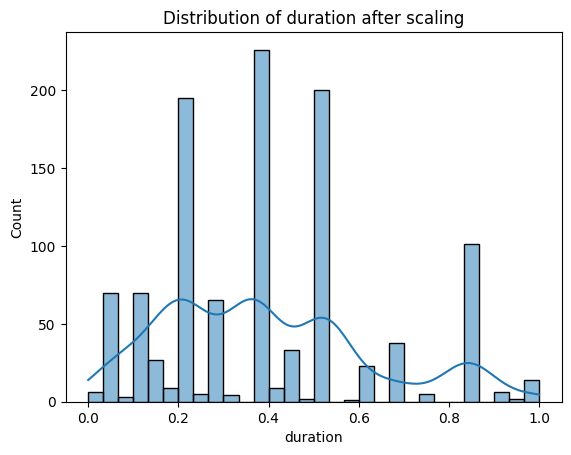

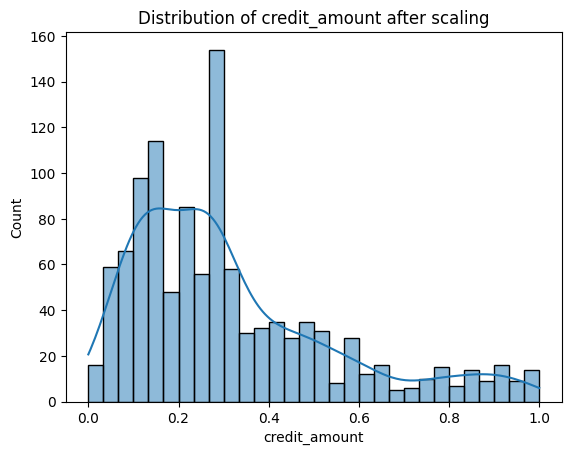

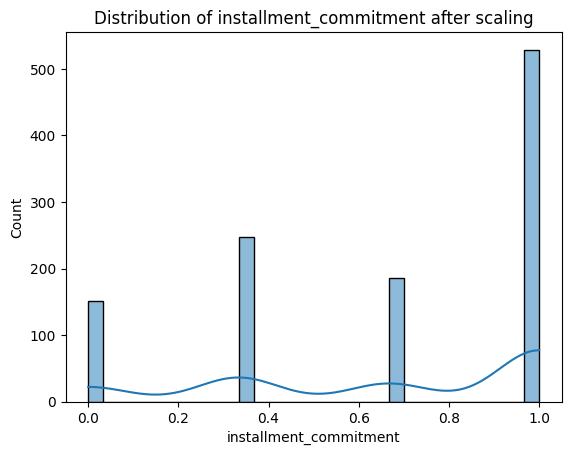

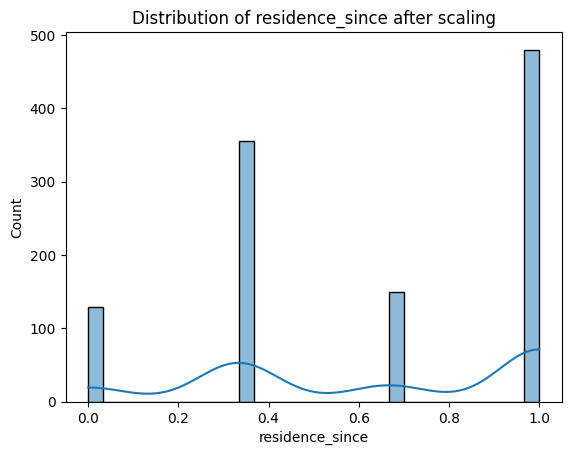

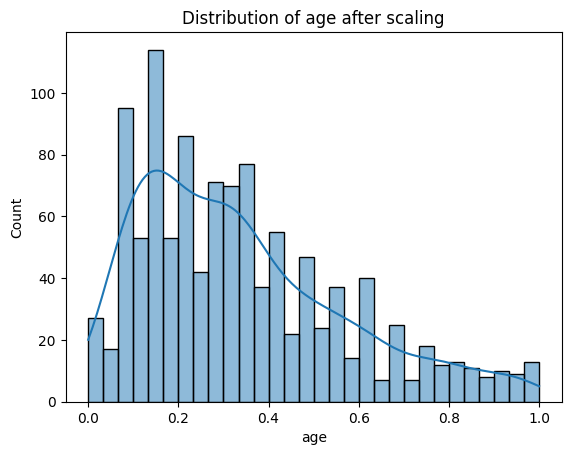

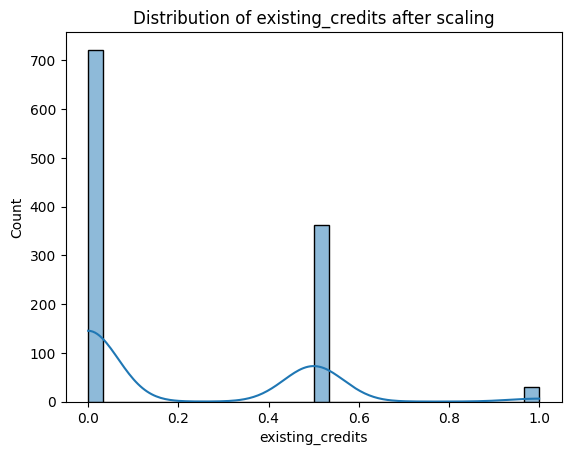

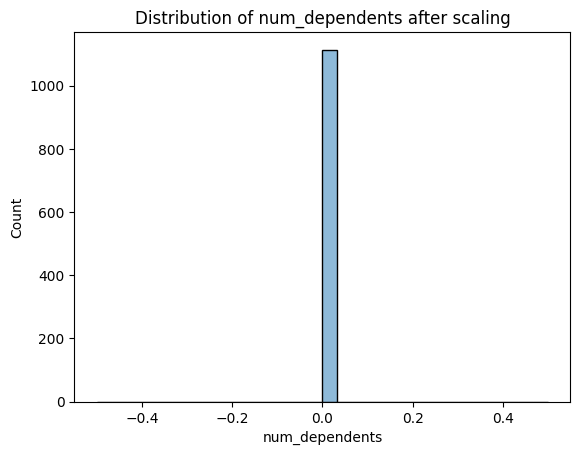

In [44]:
for col in x_train_num.columns:
  sns.histplot(x_train_num[col], kde=True, bins=30)
  plt.title(f'Distribution of {col} after scaling')
  plt.show()

In [45]:
x_train[x_train_num.columns] = x_train_num
x_test[x_test_num.columns] = x_test_num

In [46]:
x_train_cat = x_train.select_dtypes(['object'])
x_test_cat = x_test.select_dtypes(['object'])

In [47]:
le = LabelEncoder()

In [48]:
for col in x_train_cat.columns:
  x_train_cat[col] = le.fit_transform(x_train_cat[col])
  x_test_cat[col] = le.transform(x_test_cat[col])


In [49]:
x_train[x_train_cat.columns] = x_train_cat
x_test[x_test_cat.columns] = x_test_cat

In [50]:
y_train = pd.DataFrame(le.fit_transform(y_train),
                           columns = y_train.columns)
y_test = pd.DataFrame(le.transform(y_test),
                           columns = y_test.columns)

In [51]:
y_train

,class
0,1
1,0
2,1
3,0
4,1
...,...
1109,0
1110,0
1111,0
1112,0


In [52]:
x_train.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,0,0.289474,3,7,0.165618,0,0,1.000000,3,1,0.333333,3,0.066667,1,1,0.0,1,0.0,0,1
1,0,0.210526,3,6,0.067610,1,0,1.000000,3,2,0.666667,3,0.311111,1,1,0.0,3,0.0,0,1
2,3,0.368421,3,0,0.172694,0,0,0.666667,0,2,1.000000,1,0.111111,1,2,0.0,3,0.0,0,1
3,4,0.210526,3,6,0.055556,0,1,1.000000,2,2,0.000000,1,0.022222,1,1,0.0,1,0.0,0,1
4,3,0.210526,3,6,0.068920,2,0,1.000000,2,2,0.333333,3,0.200000,1,1,0.0,1,0.0,0,1


In [53]:
y_train.head()

,class
0,1
1,0
2,1
3,0
4,1
